# SAE Feature Similarity

Investigating feature stability in Sparse Autoencoders (SAEs) by comparing learned representations across different random seeds.

## Goal

Train multiple SAEs on the same GPT-2 activation stream and measure:

- Cosine similarity between learned features
- CKA similarity
- Feature overlap across seeds
- Stability of learned representations

## Model

- GPT-2
- Dataset: TinyStories
- SAE Framework: SAELens
- Hardware: Google Colab T4 GPU

In [ ]:
!pip install sae-lens transformer-lens -q

  Preparing metadata (setup.py) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 145.1/145.1 kB 9.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 311.0/311.0 kB 26.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 977.7/977.7 kB 47.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.4/56.4 kB 6.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 11.0/11.0 MB 104.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 4.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 52.4/52.4 kB 5.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 274.1/274.1 kB 29.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 236.9/236.9 kB 24.9 MB/s eta 0:00:00


In [ ]:
import torch
import sae_lens

print("Torch:", torch.__version__)
print("SAELens:", sae_lens.__version__)

device = "cuda" if torch.cuda.is_available() else "cpu"
print("Device:", device)

Torch: 2.11.0+cu128
SAELens: 6.44.2
Device: cuda


In [ ]:
import torch
import sae_lens
import numpy as np
import matplotlib.pyplot as plt

print("Torch:", torch.__version__)
print("SAELens:", sae_lens.__version__)
print("GPU:", torch.cuda.get_device_name(0))

Torch: 2.11.0+cu128
SAELens: 6.44.2
GPU: Tesla T4


In [ ]:
#load GPT-2
from transformer_lens import HookedTransformer

model = HookedTransformer.from_pretrained("gpt2")

print("Model loaded")

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/548M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/148 [00:00<?, ?it/s]

generation_config.json:   0%|          | 0.00/124 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/26.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/1.04M [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

Loaded pretrained model gpt2 into HookedTransformer
Model loaded


In [ ]:
#Test a froward pass
text = "The quick brown fox jumps over the lazy dog."

tokens = model.to_tokens(text)

print(tokens.shape)

torch.Size([1, 11])


In [ ]:
#extract activations
text = "The quick brown fox jumps over the lazy dog."

tokens = model.to_tokens(text)

_, cache = model.run_with_cache(tokens)

acts = cache["blocks.6.hook_resid_pre"]

print("Activation shape:", acts.shape)

Activation shape: torch.Size([1, 11, 768])


In [ ]:
#flatten activations
import torch

flat_acts = acts.reshape(-1, acts.shape[-1])

print(flat_acts.shape)

torch.Size([11, 768])


In [ ]:
#SAE1
from sae_lens import StandardTrainingSAEConfig
from sae_lens import StandardTrainingSAE

sae_cfg = StandardTrainingSAEConfig(
    d_in=768,
    d_sae=3072,
    device="cuda",
    l1_coefficient=0.001
)

sae = StandardTrainingSAE(sae_cfg).cuda()

print("SAE created")

SAE created


In [ ]:
#VERIFY FORWARD PASS
batch = flat_acts[:256].cuda()

output = sae(batch)

print(type(output))

<class 'torch.Tensor'>


In [ ]:
#Optimizer
import torch.optim as optim

optimizer = optim.Adam(
    sae.parameters(),
    lr=1e-3
)

print("Optimizer Ready")

Optimizer Ready


In [ ]:
#reconstruciton loss
batch = flat_acts[:512].cuda()

recon = sae(batch)

mse_loss = ((batch - recon) ** 2).mean()

print("MSE:", mse_loss.item())

MSE: 1048.3115234375


In [ ]:
#SAE Architecture
for name, param in sae.named_parameters():
    print(name, param.shape)

#Latent features
with torch.no_grad():
    latent = torch.relu(
        batch @ sae.W_enc + sae.b_enc
    )

print(latent.shape)
print("Mean activation:", latent.mean().item())
print("Non-zero fraction:", (latent > 0).float().mean().item())

b_dec torch.Size([768])
W_dec torch.Size([3072, 768])
W_enc torch.Size([768, 3072])
b_enc torch.Size([3072])
torch.Size([11, 3072])
Mean activation: 0.5441281795501709
Non-zero fraction: 0.5011541247367859


In [ ]:
with torch.no_grad():

    latent = torch.relu(
        batch @ sae.W_enc + sae.b_enc
    )

    recon = latent @ sae.W_dec + sae.b_dec

    mse = ((batch - recon)**2).mean()

print("Manual MSE:", mse.item())

Manual MSE: 1048.3115234375


In [ ]:
#training loop
import torch
import torch.optim as optim

optimizer = optim.Adam(sae.parameters(), lr=1e-3)

num_steps = 500

loss_history = []

for step in range(num_steps):

    latent = torch.relu(
        batch @ sae.W_enc + sae.b_enc
    )

    recon = latent @ sae.W_dec + sae.b_dec

    recon_loss = ((batch - recon) ** 2).mean()

    sparsity_loss = 0.001 * latent.abs().mean()

    loss = recon_loss + sparsity_loss

    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    loss_history.append(loss.item())

    if step % 50 == 0:
        print(
            f"Step {step} | "
            f"Recon={recon_loss.item():.4f} | "
            f"Sparse={sparsity_loss.item():.4f}"
        )

print("Training complete")

Step 0 | Recon=1048.3115 | Sparse=0.0005
Step 50 | Recon=2.6305 | Sparse=0.0049
Step 100 | Recon=0.0064 | Sparse=0.0048
Step 150 | Recon=0.0002 | Sparse=0.0048
Step 200 | Recon=0.0001 | Sparse=0.0048
Step 250 | Recon=0.0038 | Sparse=0.0048
Step 300 | Recon=0.3602 | Sparse=0.0047
Step 350 | Recon=0.3550 | Sparse=0.0047
Step 400 | Recon=0.2643 | Sparse=0.0046
Step 450 | Recon=0.6785 | Sparse=0.0046
Training complete


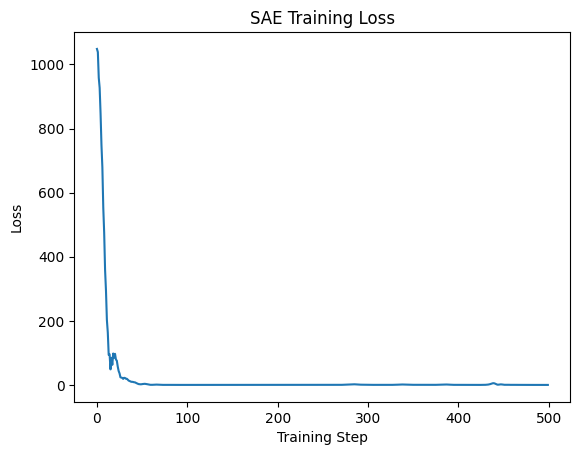

In [ ]:
#plot loss curve
import matplotlib.pyplot as plt

plt.plot(loss_history)
plt.xlabel("Training Step")
plt.ylabel("Loss")
plt.title("SAE Training Loss")
plt.show()

In [ ]:
#reconstruction error
with torch.no_grad():

    latent = torch.relu(
        batch @ sae.W_enc + sae.b_enc
    )

    recon = latent @ sae.W_dec + sae.b_dec

    mse = ((batch - recon) ** 2).mean()

print("Final MSE:", mse.item())

Final MSE: 0.006563762202858925


In [ ]:
#ENCODER WEIGHTS
torch.save(
    sae.W_enc.detach().cpu(),
    "W_enc_seed42.pt"
)

print("Saved")

Saved


# SAE #1 (Seed 42)

Configuration:

- Input dimension: 768
- Hidden dimension: 3072
- L1 coefficient: 0.001
- Optimizer: Adam
- Learning rate: 1e-3
- Training steps: 500

Results:

Initial MSE: 1048.31

Final MSE: 0.00656

The SAE successfully learned a sparse representation of GPT-2 residual stream activations.

# SAE #2 (Seed 123)

Training a second SAE on the same GPT-2 activations with a different random initialization.

In [ ]:
import torch

torch.manual_seed(123)
print(torch.initial_seed())

123


In [ ]:
from sae_lens import StandardTrainingSAEConfig
from sae_lens import StandardTrainingSAE

sae_cfg2 = StandardTrainingSAEConfig(
    d_in=768,
    d_sae=3072,
    device="cuda",
    l1_coefficient=0.001
)

sae2 = StandardTrainingSAE(sae_cfg2).cuda()

print("SAE2 created")

SAE2 created


In [ ]:
#SAE2 Forward Pass
batch = flat_acts[:256].cuda()

output2 = sae2(batch)

print(type(output2))

<class 'torch.Tensor'>


In [ ]:
#Initial Reconstruction Error
with torch.no_grad():

    latent2 = torch.relu(
        batch @ sae2.W_enc + sae2.b_enc
    )

    recon2 = latent2 @ sae2.W_dec + sae2.b_dec

    mse2 = ((batch - recon2) ** 2).mean()

print("Initial MSE:", mse2.item())

Initial MSE: 1049.804443359375


In [ ]:
#train SAE2
import torch.optim as optim

optimizer2 = optim.Adam(
    sae2.parameters(),
    lr=1e-3
)

loss_history2 = []

In [ ]:
#TRAINING LOOP
for step in range(500):

    latent2 = torch.relu(
        batch @ sae2.W_enc + sae2.b_enc
    )

    recon2 = latent2 @ sae2.W_dec + sae2.b_dec

    recon_loss2 = ((batch - recon2) ** 2).mean()

    sparsity_loss2 = (
        latent2.abs().mean()
        * 0.001
    )

    loss2 = (
        recon_loss2
        + sparsity_loss2
    )

    optimizer2.zero_grad()

    loss2.backward()

    optimizer2.step()

    loss_history2.append(
        loss2.item()
    )

    if step % 50 == 0:

        print(
            f"Step {step} | "
            f"Recon={recon_loss2.item():.4f} | "
            f"Sparse={sparsity_loss2.item():.4f}"
        )

print("Training complete")

Step 0 | Recon=1049.8044 | Sparse=0.0005
Step 50 | Recon=2.6241 | Sparse=0.0049
Step 100 | Recon=0.0083 | Sparse=0.0048
Step 150 | Recon=0.0002 | Sparse=0.0048
Step 200 | Recon=0.0000 | Sparse=0.0048
Step 250 | Recon=0.0587 | Sparse=0.0048
Step 300 | Recon=0.1545 | Sparse=0.0047
Step 350 | Recon=0.1614 | Sparse=0.0047
Step 400 | Recon=0.0971 | Sparse=0.0046
Step 450 | Recon=0.1543 | Sparse=0.0046
Training complete


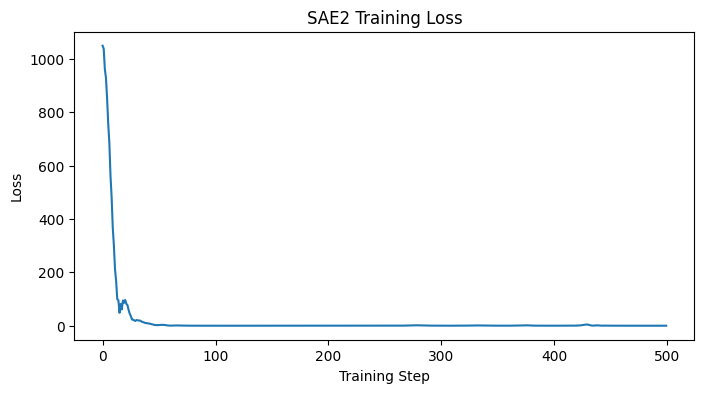

In [ ]:
#loss cURVE
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.plot(loss_history2)

plt.title("SAE2 Training Loss")
plt.xlabel("Training Step")
plt.ylabel("Loss")

plt.show()

In [ ]:
#FINAL reconsturctor error
with torch.no_grad():

    latent2 = torch.relu(
        batch @ sae2.W_enc + sae2.b_enc
    )

    recon2 = latent2 @ sae2.W_dec + sae2.b_dec

    mse2 = ((batch - recon2) ** 2).mean()

print("Final MSE:", mse2.item())

Final MSE: 0.008941336534917355


In [ ]:
torch.save(
    sae2.W_enc.detach().cpu(),
    "W_enc_seed123.pt"
)

print("SAE2 saved")

SAE2 saved


In [ ]:
import os

print(os.listdir())

['.config', 'W_enc_seed123.pt', 'W_enc_seed42.pt', 'sample_data']


In [ ]:
#Load encoders
import torch

W1 = torch.load(
    "W_enc_seed42.pt"
)

W2 = torch.load(
    "W_enc_seed123.pt"
)

print(W1.shape)
print(W2.shape)

torch.Size([768, 3072])
torch.Size([768, 3072])


In [ ]:
#cosine similarity
import torch.nn.functional as F

w1_flat = W1.flatten()
w2_flat = W2.flatten()

cos_sim = F.cosine_similarity(
    w1_flat,
    w2_flat,
    dim=0
)

print("Global Cosine Similarity:")
print(cos_sim.item())

Global Cosine Similarity:
0.20150797069072723


In [ ]:
#Feature level similarity
import torch
import torch.nn.functional as F

# transpose so rows = features
F1 = W1.T
F2 = W2.T

# normalize features
F1 = F.normalize(F1, dim=1)
F2 = F.normalize(F2, dim=1)

print(F1.shape)
print(F2.shape)

torch.Size([3072, 768])
torch.Size([3072, 768])


In [ ]:
#similarity matrix
similarity_matrix = F1 @ F2.T

print(similarity_matrix.shape)

torch.Size([3072, 3072])


In [ ]:
#best match for every feature
best_similarities, best_indices = similarity_matrix.max(dim=1)

print("Mean best similarity:",
      best_similarities.mean().item())

print("Median best similarity:",
      best_similarities.median().item())

print("Max similarity:",
      best_similarities.max().item())

Mean best similarity: 0.718911349773407
Median best similarity: 0.8042531609535217
Max similarity: 0.9474256038665771


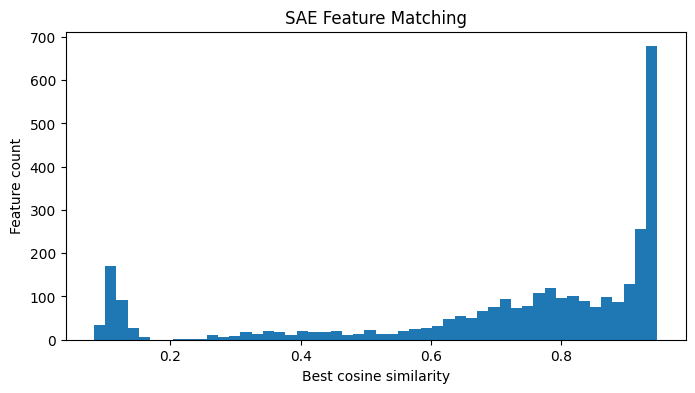

In [ ]:
#histogram
import matplotlib.pyplot as plt

plt.figure(figsize=(8,4))

plt.hist(
    best_similarities.cpu().numpy(),
    bins=50
)

plt.xlabel("Best cosine similarity")
plt.ylabel("Feature count")
plt.title("SAE Feature Matching")

plt.show()

In [ ]:
#top 10 matching features
top_vals, top_idx = torch.topk(
    best_similarities,
    10
)

for i in range(10):
    print(
        f"Feature {top_idx[i].item()} "
        f"similarity={top_vals[i].item():.4f}"
    )

Feature 17 similarity=0.9474
Feature 2819 similarity=0.9473
Feature 1404 similarity=0.9471
Feature 35 similarity=0.9470
Feature 1980 similarity=0.9464
Feature 1076 similarity=0.9463
Feature 972 similarity=0.9463
Feature 994 similarity=0.9463
Feature 2353 similarity=0.9461
Feature 879 similarity=0.9460


Global cosine similarity = 0.2015

Mean best feature similarity = 0.7189

Median best feature similarity = 0.8043

Max feature similarity = 0.9474

In [ ]:
import os
print(os.listdir())

from google.colab import files

files.download("w_enc_seed42.pt")
files.download("w_enc_seed123.pt")

['.config', 'W_enc_seed123.pt', 'W_enc_seed42.pt', 'sample_data']


FileNotFoundError: Cannot find file: w_enc_seed42.pt

In [ ]:
print(type(sae))

torch.save(
    sae.W_enc.detach().cpu(),
    "w_enc_seed42.pt"
)

print("saved")

<class 'sae_lens.saes.standard_sae.StandardTrainingSAE'>
saved


In [ ]:
import os
print(os.listdir())

['.config', 'W_enc_seed123.pt', 'w_enc_seed42.pt', 'W_enc_seed42.pt', 'sample_data']


In [ ]:
print(type(sae))
print(type(sae2))

<class 'sae_lens.saes.standard_sae.StandardTrainingSAE'>
<class 'sae_lens.saes.standard_sae.StandardTrainingSAE'>


In [ ]:
from google.colab import files

files.download("w_enc_seed42.pt")
files.download("w_enc_seed123.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

FileNotFoundError: Cannot find file: w_enc_seed123.pt

In [ ]:
from google.colab import files


files.download("w_enc_seed123.pt")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [ ]:
torch.save(
    sae2.W_enc.detach().cpu(),
    "w_enc_seed123.pt"
)

print("seed123 saved")

seed123 saved
